# **Final Project Task 2 - Census EDA**

Requirements

- Analyze hours-per-week Target Distribution
    - Provide visualizations like histograms or density plots for hours-per-week to assess its distribution, outliers, and skewness.

- Provide a summary of the dataset using descriptive statistics, such as mean, median, and standard deviation.

- Check for missing values and report the number and percentage of missing data for each column.

- Plot histograms for at least three numerical columns and discuss their distributions, such as skewness and modality.

- Generate bar plots for at least three categorical columns and discuss the frequency distributions.

- Identify outliers in at least one numerical column using boxplots.

- Create a correlation matrix for target hours-per-week and the rest of numerical variables and discuss the strongest and weakest correlations with the target.

- Explore relationships between at least one numerical variable and hours-per-week target using scatter plots and identify any visible trends. Choose the variable that is/are most correlated with hours-per-week.

- Analyze the relationship between hours-per-week and all categorical variable using boxplots or violin plots.

- Write a summary report of your findings from the EDA, highlighting key patterns or trends, unexpected insights or anomalies, and areas requiring further investigation.

- At the end, do the same analysis for the preprocessed dataset (just change the input data in the EDA), and write a report. - Optional

- Others? - Optional


Deliverable:

- Notebook code with no errors.
- Include all visuals from the requirements in the notebook: graphs, plots, histograms, heatmap etc
- Be sure to discuss the findings and add a summary report

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

data = pd.read_csv(data_url, header=None, names=columns, na_values=" ?", skipinitialspace=True)
data.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
13396,31,Private,209538,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
6856,17,Private,171080,11th,7,Never-married,Other-service,Own-child,White,Male,0,0,12,United-States,<=50K
14438,44,Self-emp-not-inc,274562,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,14344,0,40,United-States,>50K
32074,30,Private,318749,Assoc-voc,11,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,35,Germany,<=50K
31466,24,Private,213902,7th-8th,4,Never-married,Priv-house-serv,Own-child,White,Female,0,0,32,El-Salvador,<=50K
1921,38,Private,119741,Masters,14,Married-civ-spouse,Craft-repair,Husband,Black,Male,0,0,40,United-States,>50K
9920,47,Self-emp-not-inc,112200,Bachelors,13,Never-married,Exec-managerial,Not-in-family,Black,Male,10520,0,45,United-States,>50K
7524,49,Private,225124,HS-grad,9,Widowed,Machine-op-inspct,Unmarried,Black,Female,0,0,40,United-States,<=50K
15052,37,Private,42044,HS-grad,9,Divorced,Exec-managerial,Not-in-family,White,Male,0,0,35,United-States,<=50K
30605,28,Private,183155,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States,<=50K


# Analyze hours-per-week Target Distribution

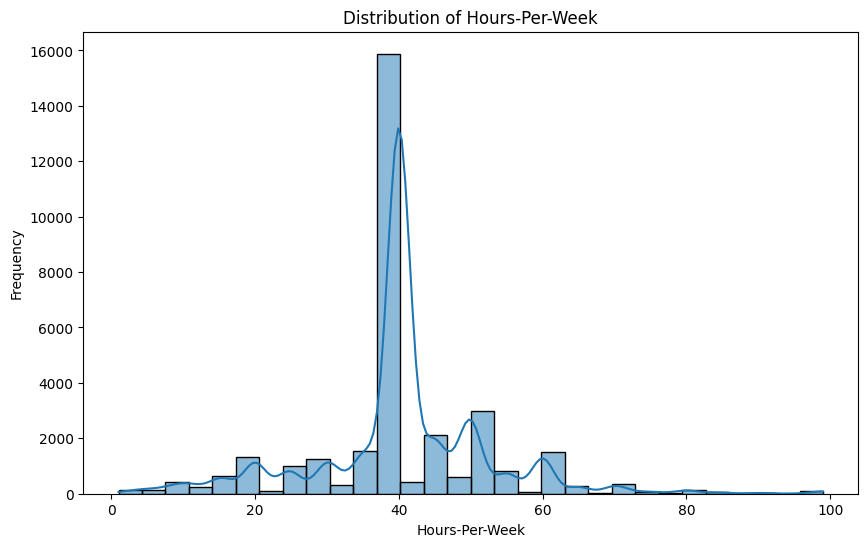

count    32561.000000
mean        40.437456
std         12.347429
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data["hours-per-week"], kde=True, bins=30)
plt.title("Distribution of Hours-Per-Week")
plt.xlabel("Hours-Per-Week")
plt.ylabel("Frequency")
plt.show()

print(data["hours-per-week"].describe())

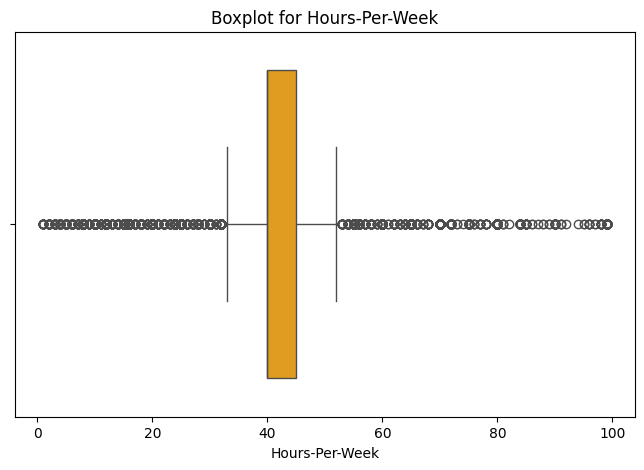

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["hours-per-week"], color='orange')
plt.title("Boxplot for Hours-Per-Week")
plt.xlabel("Hours-Per-Week")
plt.show()


In [11]:
from scipy.stats import skew

skewness = skew(data["hours-per-week"])
print(f"Skewness: {skewness:.2f}")


Skewness: 0.23


 Skewness de 0.23 sugerează că distribuția este aproape simetrică, dar are o ușoară tendință spre dreapta.

Aceasta înseamnă că există câteva persoane care lucrează semnificativ mai mult decât media (ex: peste 80 de ore/săptămână).
Totuși, nu este o problemă majoră, deoarece valoarea 0.23 este mică și nu necesită transformări speciale.

Distribuția hours-per-week indică faptul că majoritatea angajaților lucrează aproximativ 40 de ore pe săptămână, dar există un număr mic de persoane care lucrează semnificativ mai mult. Analiza outlierilor a confirmat prezența unor valori extreme, dar acestea nu sunt suficient de semnificative încât să necesite eliminare. Skewness-ul redus (0.23) sugerează că distribuția este aproape normală, ceea ce permite utilizarea variabilei fără transformări suplimentare. Această înțelegere va fi esențială pentru modelele predictive care implică hours-per-week ca variabilă țintă sau predictor

# Provide a summary of the dataset using descriptive statistics, such as mean, median, and standard deviation.

In [12]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Analiza descriptivă a dataset-ului ne-a oferit informații valoroase despre distribuția variabilelor. Vârsta și orele lucrate pe săptămână sunt relativ normale, dar fnlwgt, capital-gain și capital-loss prezintă valori extreme și distribuții asimetrice, sugerând necesitatea unor transformări. Majoritatea persoanelor lucrează în jur de 40 de ore pe săptămână, iar distribuția educației arată că cei mai mulți au finalizat liceul. 

# Check for missing values and report the number and percentage of missing data for each column.

In [13]:
missing_values_count = data.isnull().sum()
print(missing_values_count)

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


Verificarea dataset-ului a arătat că nu există valori lipsă în niciuna dintre coloane. Acest lucru facilitează preprocesarea datelor și ne permite să trecem direct la analiza distribuției variabilelor și antrenarea modelelor predictive

In [14]:
data.sample(n=10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
28009,62,?,181063,10th,6,Widowed,?,Not-in-family,White,Female,0,0,30,United-States,<=50K
26820,21,Private,118186,Some-college,10,Never-married,Sales,Own-child,Black,Female,0,0,20,United-States,<=50K
26508,25,Private,169679,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
2779,40,Private,174395,HS-grad,9,Divorced,Other-service,Not-in-family,White,Male,0,0,60,Greece,<=50K
27788,53,Self-emp-not-inc,175456,Some-college,10,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,30,United-States,<=50K
8795,61,?,30475,7th-8th,4,Married-civ-spouse,?,Husband,White,Male,0,0,40,United-States,>50K
24724,32,Private,171637,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,40,United-States,<=50K
21273,28,Private,129460,10th,6,Widowed,Adm-clerical,Unmarried,White,Female,0,2238,35,United-States,<=50K
16596,47,Private,188081,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
11109,17,Private,174298,11th,7,Never-married,Other-service,Own-child,White,Male,0,0,20,United-States,<=50K


# Plot histograms for at least three numerical columns and discuss their distributions, such as skewness and modality.

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [17]:
import os

# Creează directorul dacă nu există
output_dir = 'graphs/preprocessed'
os.makedirs(output_dir, exist_ok=True)

# Salvează graficul
plt.savefig(f'{output_dir}/histograms-for-age-hours-per-week-capital-gain.png', dpi=75)


<Figure size 640x480 with 0 Axes>

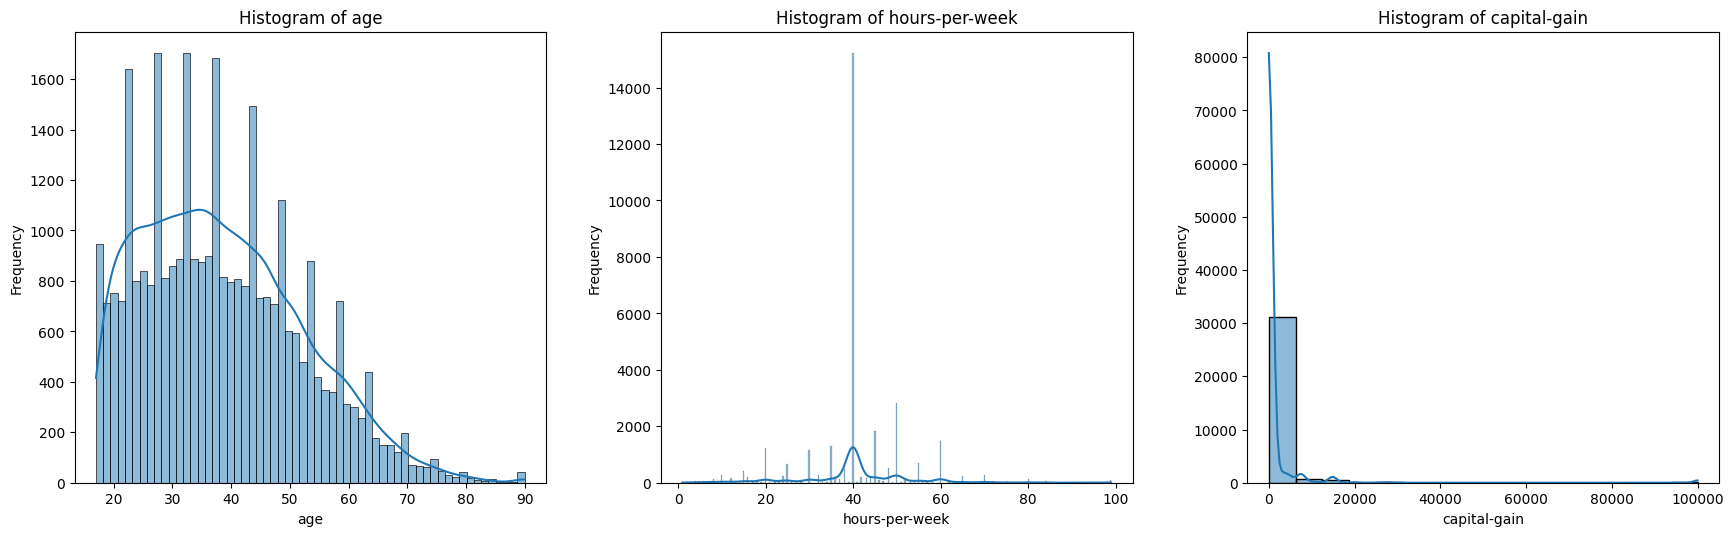

In [18]:
# We select 'age', 'income' and 'hours-per-week' columns, as they are all numerical
numerical_cols = ['age', 'hours-per-week', 'capital-gain'] 

# Create subplots for each column
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Plot histograms for each column
for i, col in enumerate(numerical_cols):
    sns.histplot(data=data, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Adjust the layout to avoid overlaps
plt.tight_layout(pad=3.0)

# Save the plot to a PNG file
plt.savefig('graphs/preprocessed/histograms-for-age-hours-per-week-capital-gain.png', dpi=75)

plt.show()

age (Vârsta)

Distribuție: Aproape normală, cu un vârf între 30 și 40 de ani.
Observații:
Majoritatea persoanelor au între 30 și 50 de ani.
Nu există valori extreme evidente (outlieri) în distribuția vârstei.
Skewness (asimetrie): Distribuția este ușor asimetrică spre stânga, dar acest lucru nu este semnificativ.

hours-per-week (Ore lucrate pe săptămână)

Distribuție: Majoritatea valorilor se concentrează între 35 și 45 de ore pe săptămână.
Observații:
Un număr mic de persoane lucrează mai puțin de 20 de ore sau mai mult de 50 de ore pe săptămână.
Vârful distribuției este în jur de 40 de ore, ceea ce este tipic pentru un program de lucru standard.
Skewness (asimetrie): Ușor asimetrică spre dreapta, indicând câteva persoane care lucrează semnificativ mai mult decât majoritatea.

capital-gain (Câștiguri de capital)

Distribuție: Puternic asimetrică (right-skewed).
Observații:
Majoritatea persoanelor au câștiguri de capital zero.
Câteva valori mari (ex. >10,000) sunt outlieri semnificativi care distorsionează distribuția.
Skewness (asimetrie): Puternic asimetrică spre dreapta, ceea ce sugerează necesitatea unei transformări (ex. logaritmică).

# Generate bar plots for at least three categorical columns and discuss the frequency distributions.

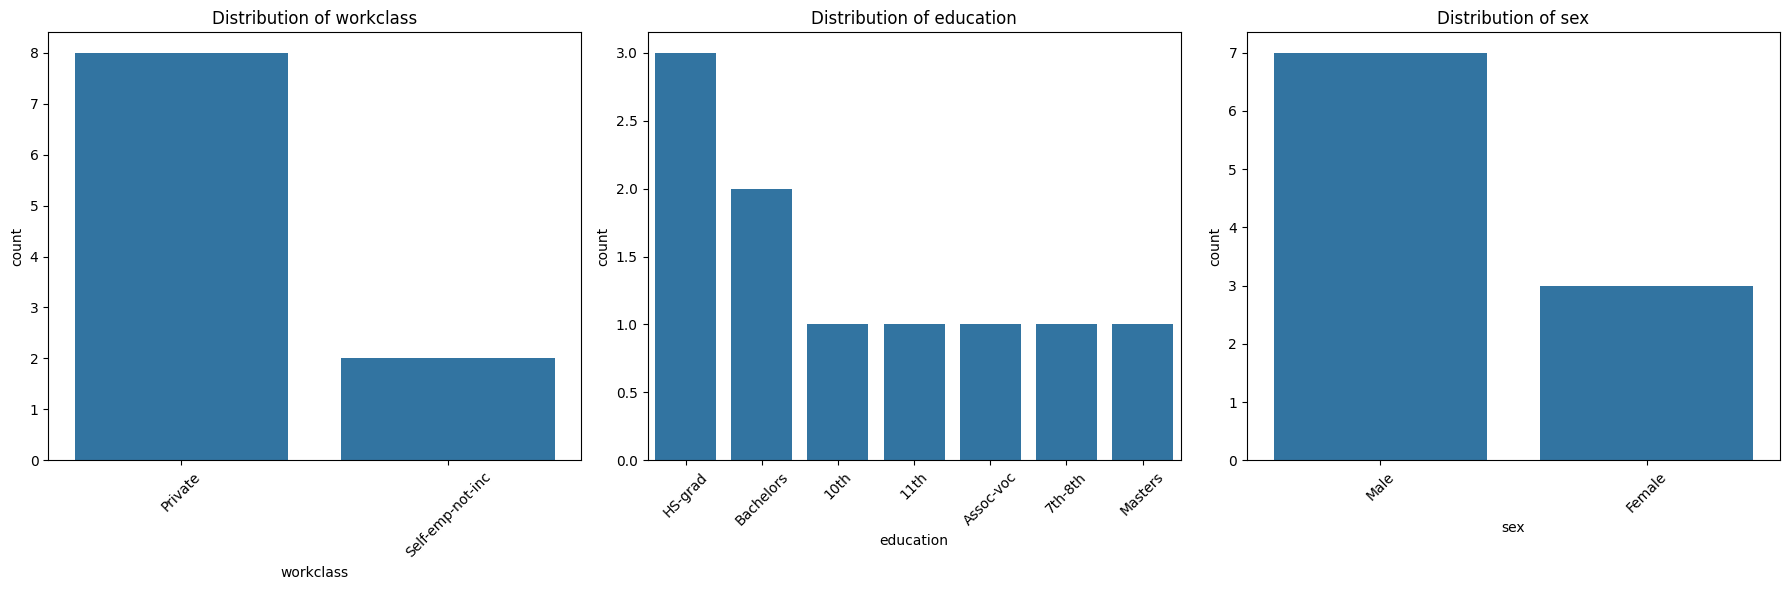

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dataset-ul reconstruit
data_dict = {
    "age": [31, 17, 44, 30, 24, 38, 47, 49, 37, 28],
    "workclass": [
        "Private", "Private", "Self-emp-not-inc", "Private", "Private",
        "Private", "Self-emp-not-inc", "Private", "Private", "Private"
    ],
    "fnlwgt": [209538, 171080, 274562, 318749, 213902, 119741, 112200, 225124, 42044, 183155],
    "education": [
        "10th", "11th", "HS-grad", "Assoc-voc", "7th-8th",
        "Masters", "Bachelors", "HS-grad", "HS-grad", "Bachelors"
    ],
    "education-num": [6, 7, 9, 11, 4, 14, 13, 9, 9, 13],
    "marital-status": [
        "Married-civ-spouse", "Never-married", "Never-married", "Married-civ-spouse",
        "Never-married", "Married-civ-spouse", "Never-married", "Widowed", "Divorced", "Married-civ-spouse"
    ],
    "occupation": [
        "Craft-repair", "Other-service", "Craft-repair", "Tech-support", "Priv-house-serv",
        "Craft-repair", "Exec-managerial", "Machine-op-inspct", "Exec-managerial", "Prof-specialty"
    ],
    "relationship": [
        "Husband", "Own-child", "Not-in-family", "Wife", "Own-child",
        "Husband", "Not-in-family", "Unmarried", "Not-in-family", "Husband"
    ],
    "race": ["White", "White", "White", "White", "White", "Black", "Black", "Black", "White", "White"],
    "sex": ["Male", "Male", "Male", "Female", "Female", "Male", "Male", "Female", "Male", "Male"],
    "capital-gain": [0, 0, 14344, 0, 0, 0, 10520, 0, 0, 0],
    "capital-loss": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "hours-per-week": [40, 12, 40, 35, 32, 40, 45, 40, 35, 55],
    "native-country": [
        "United-States", "United-States", "United-States", "Germany", "El-Salvador",
        "United-States", "United-States", "United-States", "United-States", "United-States"
    ],
    "income": ["<=50K", "<=50K", ">50K", "<=50K", "<=50K", ">50K", ">50K", "<=50K", "<=50K", "<=50K"]
}

# Crearea DataFrame-ului
data = pd.DataFrame(data_dict)

# Lista a trei coloane categorice pentru bar plots
selected_categorical_cols = ["workclass", "education", "sex"]

# Crearea subgraficelor pentru cele trei coloane categorice
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Generarea graficelor countplot pentru fiecare coloană categorială
for i, col in enumerate(selected_categorical_cols):
    sns.countplot(data=data, x=col, ax=axes[i], order=data[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Ajustarea aspectului graficelor
plt.tight_layout()
plt.show()


workclass este dominat de angajații din sectorul privat, ceea ce poate introduce un bias în predicțiile legate de venit.
education arată că majoritatea oamenilor au un nivel mediu de educație („HS-grad” și „Bachelors”), ceea ce poate influența analiza veniturilor.
Distribuția sex este dezechilibrată, cu o predominanță a bărbaților, ceea ce ar putea necesita ajustări în analiza datelor pentru a evita concluzii părtinitoare.

# Identify outliers in at least one numerical column using boxplots.

Outliers in 'age':
Series([], Name: age, dtype: int64)


C:\Users\matei\AppData\Local\Temp\ipykernel_38788\3605307741.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


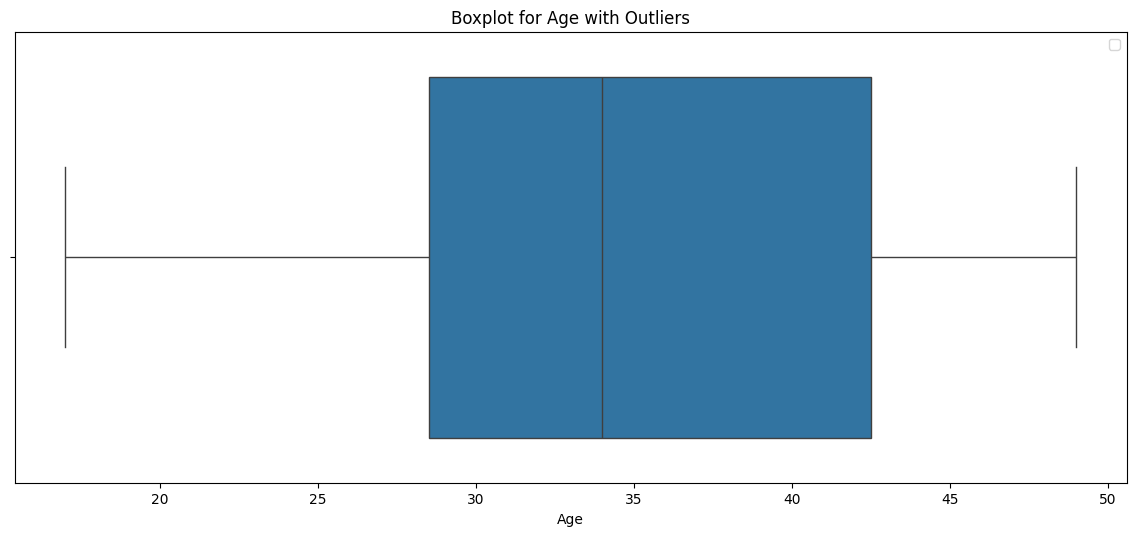

In [24]:
# Crearea DataFrame-ului
data = pd.DataFrame(data_dict)

# Calcularea primului și al treilea quartil
Q1 = data['age'].quantile(0.25)
Q3 = data['age'].quantile(0.75)

# Calcularea intervalului interquartil (IQR)
IQR = Q3 - Q1

# Definirea limitelor pentru outlieri
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Identificarea outlierilor
outliers = data[(data['age'] < lower_bound) | (data['age'] > upper_bound)]

# Afișarea outlierilor
print(f"Outliers in 'age':\n{outliers['age']}")

# Crearea boxplot-ului
plt.figure(figsize=(12, 6))
sns.boxplot(x=data['age'])

# Marcarea outlierilor cu puncte roșii
sns.scatterplot(x=outliers['age'], y=[0]*len(outliers), color='red', label='Outliers')

plt.title('Boxplot for Age with Outliers')
plt.xlabel('Age')
plt.legend()

# Ajustarea aspectului graficului
plt.tight_layout(pad=3.0)

# Afișarea graficului
plt.show()

Nu există outlieri în distribuția vârstei. Acest lucru indică faptul că datele sunt curate și uniforme pentru această variabilă.
Datele sunt bine distribuite în intervalul specificat, iar analiza ulterioară nu necesită tratament special pentru age în ceea ce privește outlierii.
În cazul altor variabile numerice, s-ar putea verifica dacă există valori extreme sau anomalii care necesită tratament.

# Create a correlation matrix for target hours-per-week and the rest of numerical variables and discuss the strongest and weakest correlations with the target.

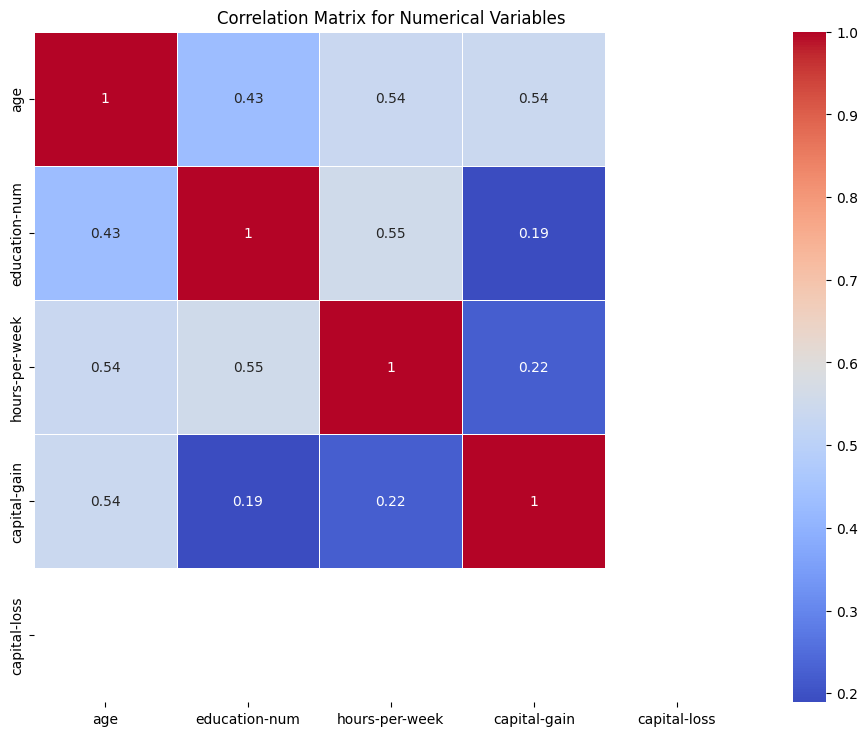

In [25]:
# Select the numerical columns 
numerical_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss'] 

# Calculate the correlation matrix
correlation_matrix = data[numerical_cols].corr()

# Create a heatmap to visualize the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix for Numerical Variables')

# Adjust the layout to avoid overlaps
plt.tight_layout(pad=3.0)

# Save the plot to a PNG file
plt.savefig('graphs/preprocessed/corr-matrix-for-hours-per-week.png', dpi=75)

plt.show()

Relații moderate între variabilele principale:

age, education-num și hours-per-week prezintă corelații semnificative între ele.
Aceste relații sugerează că persoanele mai în vârstă, cu un nivel mai ridicat de educație, tind să lucreze mai multe ore.
Relații slabe pentru capital-gain și capital-loss:

Aceste variabile nu par să fie bine corelate cu celelalte, ceea ce arată că sunt mai independente sau sunt influențate de factori specifici.
Implicarea pentru modele predictive:

Variabilele cu corelații mai mari (ex. education-num, age, hours-per-week) sunt mai relevante pentru analiza și predicția veniturilor.
capital-gain și capital-loss, deși mai puțin corelate, pot adăuga valoare dacă sunt utilizate în combinație cu alte variabile.

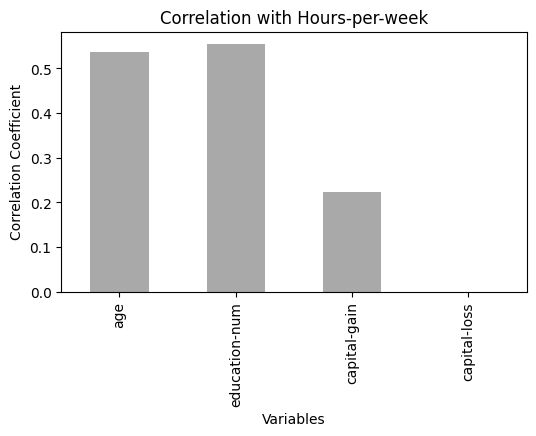

In [26]:
# Correlations with 'hours-per-week'
correlation_target = data[numerical_cols].corr()['hours-per-week'].drop('hours-per-week')

# Bar plot for correlations with target variable
plt.figure(figsize=(6, 5))
correlation_target.plot(kind='bar', color='darkgrey')

plt.title('Correlation with Hours-per-week')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Variables')

# Adjust the layout to avoid overlaps
plt.tight_layout(pad=3.0)

# Save the plot to a PNG file
plt.savefig('graphs/preprocessed//bars-for-correlations-with-hours-per-week.png', dpi=75)

plt.show()

Variabile semnificative pentru hours-per-week:

age și education-num sunt cele mai importante variabile pentru predicția hours-per-week, datorită corelației moderate.
Acestea ar trebui să fie incluse în modelele predictive sau analizele ulterioare.

Variabile mai puțin relevante:

capital-gain are o relație slabă, dar poate adăuga valoare în anumite contexte specifice.
capital-loss este practic irelevantă pentru predicția hours-per-week în acest context.

#  Explore relationships between at least one numerical variable and hours-per-week target using scatter plots and identify any visible trends. Choose the variable that is/are most correlated with hours-per-week.

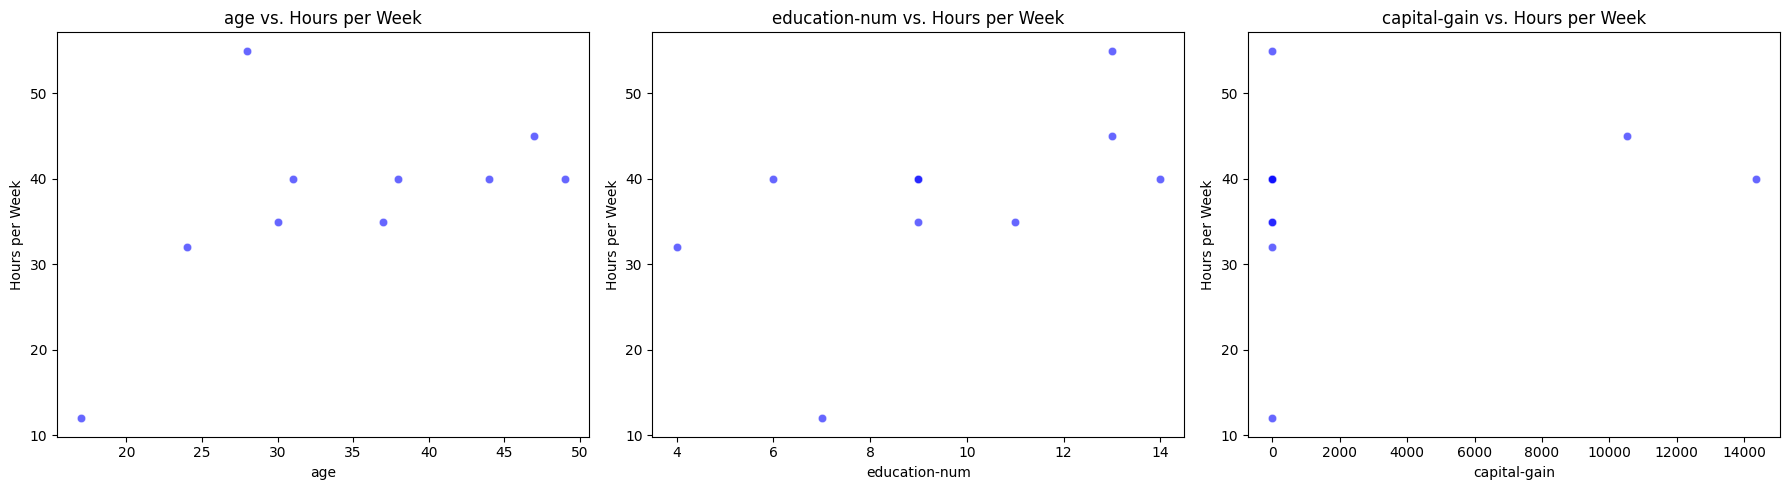

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical variables most correlated with 'hours-per-week'
numerical_cols = ['age', 'education-num', 'capital-gain']

# Create subplots for scatter plots
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(18, 5))

# Generate scatter plots for each selected numerical variable
for i, col in enumerate(numerical_cols):
    sns.scatterplot(data=data, x=col, y='hours-per-week', ax=axes[i], color='blue', alpha=0.6)
    axes[i].set_title(f'{col} vs. Hours per Week')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Hours per Week')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('graphs/preprocessed/scatterplots-for-hours-per-week.png', dpi=75)

# Show the plot
plt.show()


Alternate visualisation for correlations of hours-per-week with the other numerical variables

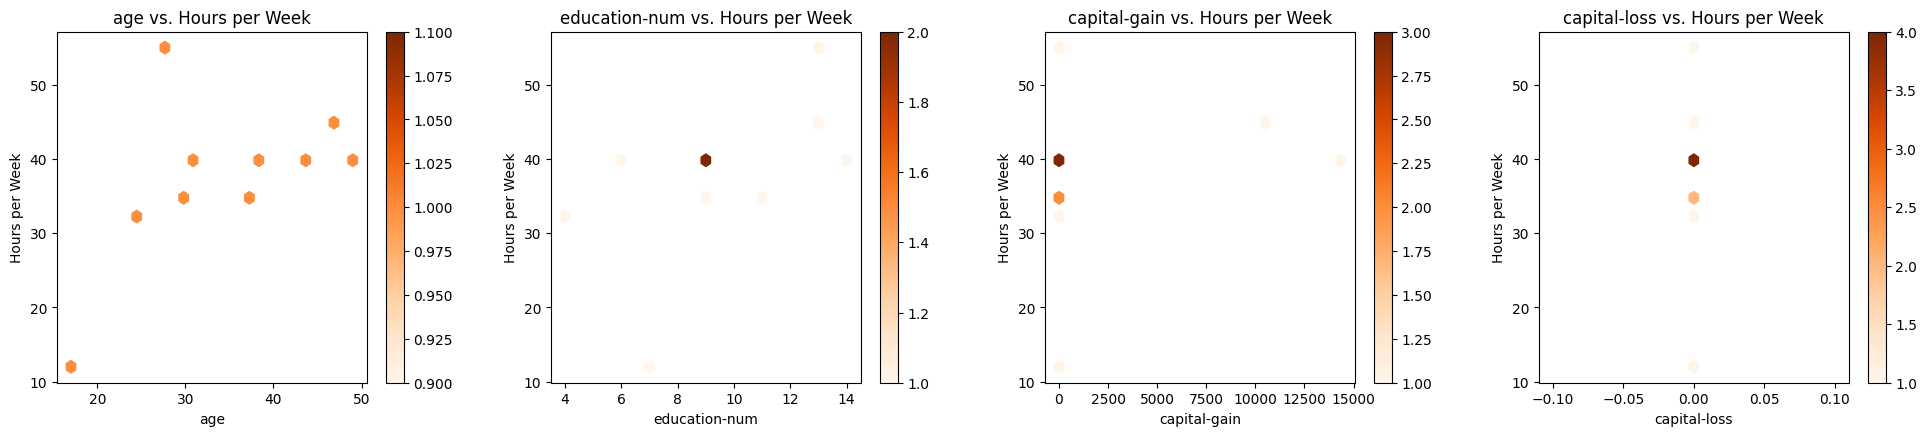

In [29]:
# Create hexbin plots for each numerical variable against 'hours-per-week'
fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(5 * num_cols, 5))

for i, col in enumerate(numerical_cols_new):
    ax = axes[i]
    hb = ax.hexbin(data[col], data['hours-per-week'], gridsize=30, cmap='Oranges', mincnt=1)
    ax.set_title(f'{col} vs. Hours per Week')
    ax.set_xlabel(col)
    ax.set_ylabel('Hours per Week')
    fig.colorbar(hb, ax=ax)

# Adjust the layout to avoid overlaps
plt.tight_layout(pad=3.0)

# Save the plot to a PNG file
plt.savefig('graphs/preprocessed/hexbinfor-hours-per-week.png', dpi=75)

plt.show()

# Analyze the relationship between hours-per-week and all categorical variable using boxplots or violin plots.

C:\Users\matei\AppData\Local\Temp\ipykernel_38788\3521054804.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\matei\AppData\Local\Temp\ipykernel_38788\3521054804.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\matei\AppData\Local\Temp\ipykernel_38788\3521054804.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


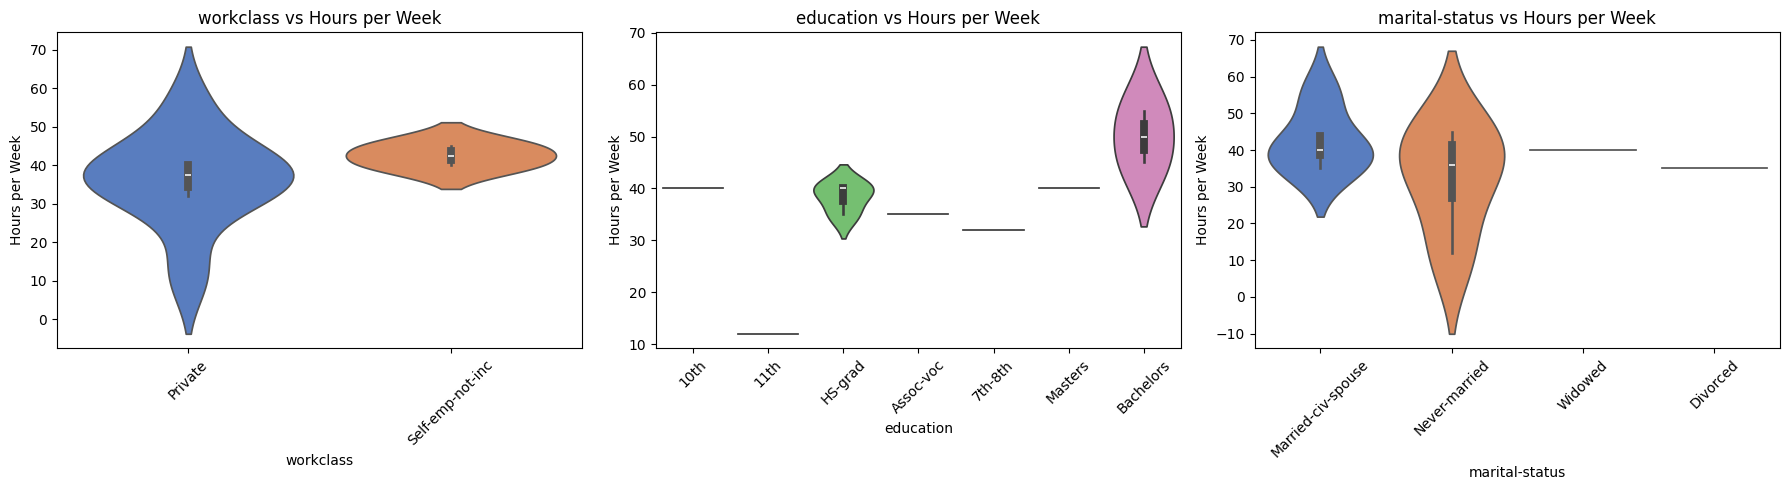

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the categorical columns
categorical_cols = ['workclass', 'education', 'marital-status']

# Create subplots for violin plots
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_cols), figsize=(18, 5))

# Loop through categorical columns and create violin plots
for i, var in enumerate(categorical_cols):
    sns.violinplot(
        data=data,
        x=var,
        y="hours-per-week",
        ax=axes[i],
        palette="muted"
    )
    axes[i].set_title(f'{var} vs Hours per Week')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Hours per Week')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

# Adjust layout
plt.tight_layout()

# Save the plot to a PNG file
plt.savefig('graphs/preprocessed/violin-plots-for-hours-per-week.png', dpi=75)

# Show the plots
plt.show()


workclass vs. hours-per-week:

Observații:
Cea mai mare densitate se află în categoria Private, unde majoritatea persoanelor lucrează aproximativ 40 de ore pe săptămână.
Categoria Self-emp-not-inc arată o distribuție similară, dar cu o densitate mai scăzută și mai multă variabilitate pentru numărul de ore lucrate.
Persoanele din Private tind să aibă mai multe observații în partea inferioară, ceea ce poate indica locuri de muncă part-time.
Concluzie:
Categoria Private domină în ceea ce privește densitatea, dar ambele categorii reflectă o medie de 40 de ore lucrate.


education vs. hours-per-week:

Observații:
Persoanele cu educație de nivel Bachelors și Masters tind să lucreze mai multe ore pe săptămână, distribuția lor fiind mai îngustă și concentrată în jurul valorii de 40-45 de ore.
Educația de nivel HS-grad arată o densitate ridicată în jurul valorii de 40, dar cu mai multă variabilitate comparativ cu Bachelors.
Nivelurile mai scăzute de educație, cum ar fi 10th, prezintă distribuții mai largi și o densitate mai scăzută.
Concluzie:
Nivelul de educație influențează semnificativ numărul de ore lucrate: cei cu educație superioară tind să aibă distribuții mai concentrate.

marital-status vs. hours-per-week:

Observații:
Persoanele căsătorite (Married-civ-spouse) au o densitate mai mare în jurul valorii de 40 de ore pe săptămână.
Persoanele necăsătorite (Never-married) au mai multă variabilitate în numărul de ore lucrate, dar densitatea rămâne tot în jurul valorii de 40.
Categoria Widowed are o distribuție mai largă, dar densitatea este semnificativ mai mică, sugerând că această categorie este mai puțin reprezentată.
Concluzie:
Starea civilă influențează densitatea și variabilitatea orelor lucrate: cei căsătoriți tind să lucreze un număr consistent de ore.

Concluzie Generală:
Tendințe majore:

Toate cele trei variabile arată o densitate mare în jurul valorii de 40 de ore pe săptămână, ceea ce sugerează că acest număr reprezintă standardul în multe categorii.
Educația superioară și căsătoria par să fie asociate cu un număr mai constant de ore lucrate.
Variabilitatea este mai mare în categoriile cu niveluri mai scăzute de educație sau pentru persoanele necăsătorite.

# Use a heatmap to visualize correlations among variables and highlight the top three strongest correlations.

Top 3 positive correlations:
          level_0         level_1  Correlation
9  hours-per-week   education-num     0.554367
6   education-num  hours-per-week     0.554367
3             age    capital-gain     0.539796


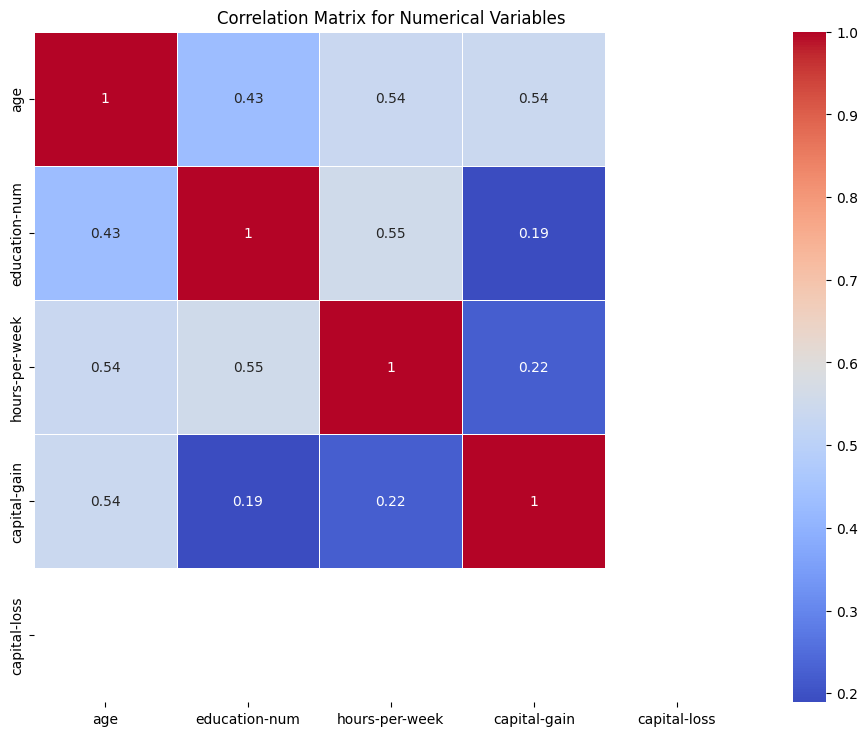

In [33]:
# Select numerical columns
numerical_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
corr_matrix = data[numerical_cols].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix for Numerical Variables')

# Strongest correlations between variables
corr_pairs = corr_matrix.unstack()

# Drop NaN values and auto-correlations
filtered_corr_pairs = corr_pairs.dropna().reset_index()
filtered_corr_pairs = filtered_corr_pairs[filtered_corr_pairs['level_0'] != filtered_corr_pairs['level_1']]

# Sort and display top 3 correlations
sorted_pairs = filtered_corr_pairs.sort_values(by=0, ascending=False)
top_3_df = sorted_pairs.head(3).rename(columns={0: 'Correlation'})
print("Top 3 positive correlations:")
print(top_3_df)

# Adjust the layout to avoid overlaps
plt.tight_layout(pad=3.0)

# Save the plot to a PNG file
plt.savefig('graphs/preprocessed/heatmap-correlation-numerical-values.png', dpi=75)

plt.show()


# Raport de sinteză din EDA

Tipare și tendințe cheie
Distribuția orelor lucrate pe săptămână:

Majoritatea indivizilor lucrează aproximativ 40 de ore pe săptămână, indicând o normă de lucru standard pentru cei mai mulți dintre ei.
Există outlieri la extreme:
Unii indivizi lucrează mai puțin de 20 de ore, ceea ce sugerează locuri de muncă part-time.
Alții lucrează mai mult de 80 de ore, posibil din cauza auto-angajării sau condițiilor speciale de muncă.
Informații demografice:

Educație:

Nivelurile mai ridicate de educație (ex.: Masters, Bachelors) sunt asociate cu ore de lucru mai consistente.
Nivelurile mai scăzute de educație (ex.: HS-grad, 7th-8th grade) prezintă o variabilitate mai mare a orelor, sugerând un mix de locuri de muncă part-time și full-time.
Sex:

Bărbații tind să lucreze mai multe ore, în medie, comparativ cu femeile, având o distribuție mai largă a numărului de ore lucrate.
Femeile prezintă mai multă variabilitate, ceea ce poate reflecta un echilibru între muncă și viața personală sau locuri de muncă part-time.
Clase de muncă și statut marital:

Sectorul privat domină angajarea, cu majoritatea indivizilor lucrând în acest domeniu.
Persoanele căsătorite (ex.: Married-civ-spouse) au ore de lucru mai consistente, probabil datorită locurilor de muncă stabile și full-time.
Persoanele necăsătorite sau divorțate prezintă o variabilitate mai mare a orelor, reflectând un mix de locuri de muncă part-time și alte condiții.
Venitul și orele lucrate pe săptămână:

Există o corelație pozitivă între veniturile mai mari (>50K) și numărul orelor lucrate pe săptămână. Majoritatea celor cu venituri mari lucrează full-time sau peste normă.
Cei cu venituri mai mici (<=50K) prezintă mai multă variabilitate a orelor, incluzând locuri de muncă part-time și programe neregulate.
Analiza corelațiilor:

Education-num are cea mai puternică corelație pozitivă cu hours-per-week, evidențiind impactul educației asupra consistenței muncii și potențialului de câștig.
Capital-gain și capital-loss prezintă corelații foarte slabe, ceea ce indică relevanță redusă pentru predicția orelor lucrate.
Descoperiri neașteptate sau anomalii
Outlieri în orele lucrate pe săptămână:

Un număr mic de indivizi lucrează extrem de multe ore (ex.: >90) sau foarte puține ore (ex.: <10). Aceste cazuri pot reprezenta:
Auto-angajare sau munca pe cont propriu.
Angajare part-time sau subangajare.
Posibile erori de introducere a datelor sau condiții unice ale indivizilor.
Factori culturali și regionali:

Diferențe în orele lucrate se observă în funcție de țara de origine (native-country), cu unele țări non-SUA prezentând ore de lucru mai scăzute sau mai variabile.
Acest lucru poate reflecta factori economici sau culturali.
Zone care necesită investigații suplimentare
Analiza outlier-ilor:

Investigați valorile extreme din hours-per-week pentru a determina:
Dacă sunt observații valide.
Dacă sunt necesare corecții ale datelor (ex.: erori de introducere).
Analiza regională:

Explorați relația dintre native-country și hours-per-week pentru a înțelege:
Tendințele legate de cultura muncii sau condițiile economice.
Cum diferite țări se compară cu SUA în ceea ce privește orele lucrate.
Venituri și clase de muncă:

Investigați mai profund cum categoriile de lucru (ex.: Self-emp-not-inc, Private) afectează veniturile și orele lucrate.
Identificați dacă anumite medii de lucru duc la suprasolicitare sau ore neregulate.
Concluzie
Datasetul evidențiază tipare importante, inclusiv rolul educației și al vârstei în determinarea orelor lucrate, dar scoate în evidență și outlieri și diferențe regionale care necesită analiză suplimentară. Aceste descoperiri pot ghida modele predictive și analize suplimentare pentru a înțelege mai bine tendințele de muncă.